# Graded Response Model — Duckworth Grit Scale (Single Scale)

Fits a single-dimensional GRM to all 12 Grit Scale items.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
from bayesianquilts.data.grit import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-{response_cardinality - 1})")
print(f"Item keys: {item_keys}")
df.head()

Dataset: 4270 people, 12 items, 5 response categories (0-4)
Item keys: ['GS1', 'GS2', 'GS3', 'GS4', 'GS5', 'GS6', 'GS7', 'GS8', 'GS9', 'GS10', 'GS11', 'GS12']


person,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,GS11,GS12
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,0,2,2,2,1,2,0,2,1,2,2
1,1,1,2,2,1,0,2,2,1,0,2,1
2,2,2,2,2,3,2,3,3,2,2,2,2
3,0,2,3,1,3,0,4,3,0,0,2,0
4,0,1,2,2,1,1,1,3,2,2,3,3


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 4270


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 183
N: 4270, Batch size: 256, Steps per epoch: 17


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200

losses_baseline, params_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
)

print(f"Final baseline loss: {losses_baseline[-1]:.2f}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: /tmp/checkpoints
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:04<?, ?batch/s, best_loss=inf, loss=16544.4456]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:04<01:04,  4.04s/batch, best_loss=inf, loss=16544.4456]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:04<01:04,  4.04s/batch, best_loss=inf, loss=16516.6068]

...

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 14/17 [00:00<00:00, 130.64batch/s, best_loss=6133.5282, loss=6144.9321]

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 14/17 [00:00<00:00, 130.64batch/s, best_loss=6133.5282, loss=6209.3861]

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 14/17 [00:00<00:00, 130.64batch/s, best_loss=6133.5282, loss=6336.7865]

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 14/17 [00:00<00:00, 130.64batch/s, best_loss=6133.5282, loss=4536.4252]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Restored model from checkpoint: /tmp/checkpoints/best_model_199
Final baseline loss: 6121.01


In [6]:
model_baseline.save_to_disk('grm_baseline')

## 4. Fit MICEBayesianLOO Imputation Model

In [7]:
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

mice_loo = MICEBayesianLOO(
    random_state=42,
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    pandas_df,
    n_top_features=12,
    n_jobs=-1,
    fit_zero_predictors=True,
    seed=42,
)

Missing values per item:
GS1     10
GS2     14
GS3     12
GS4     34
GS5     11
GS6     14
GS7     14
GS8     10
GS9      9
GS10    15
GS11    15
GS12    25
dtype: int64
Computing feature correlations...
Fitting MICE Bayesian LOO-CV models with Pathfinder
  Variables: 12
  Observations: 4270
  Min obs per model: 5
  Parallel jobs: -1
  Top features per target: 12
  Global Ordinal Values: [0. 1. 2. 3. 4.] (n=5)

Fitting zero-predictor models...
  Scheduling 12 zero-predictor jobs...


  Var 0 (GS1): n_obs=4260, elpd/n=-0.1579
  Var 1 (GS2): n_obs=4256, elpd/n=-0.1790
  Var 2 (GS3): n_obs=4258, elpd/n=-0.1841
  Var 3 (GS4): n_obs=4236, elpd/n=-0.1846
  Var 4 (GS5): n_obs=4259, elpd/n=-0.1881
  Var 5 (GS6): n_obs=4256, elpd/n=-0.1546
  Var 6 (GS7): n_obs=4256, elpd/n=-0.1821


  Var 7 (GS8): n_obs=4260, elpd/n=-0.1899
  Var 8 (GS9): n_obs=4261, elpd/n=-0.1775
  Var 9 (GS10): n_obs=4255, elpd/n=-0.1862


  Var 10 (GS11): n_obs=4255, elpd/n=-0.1746
  Var 11 (GS12): n_obs=4245, elpd/n=-0.1687

Fitting one-predictor models...
  Processing GS1 (11 valid predictors)


  Processing GS2 (11 valid predictors)


...

  Processing GS8 (11 valid predictors)


  Processing GS9 (11 valid predictors)


  Processing GS10 (11 valid predictors)


  Processing GS11 (11 valid predictors)


  Processing GS12 (11 valid predictors)


In [8]:
mice_loo.save('mice_loo_model.yaml')

## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [9]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    imputation_model=mice_loo,
    dtype=jnp.float64,
)

model_imputed.validate_imputation_model()
print("Imputation model validation passed.")

losses_imputed, params_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
)

print(f"Final imputed loss: {losses_imputed[-1]:.2f}")

/home/josh/workspace/bayesianquilts/python/bayesianquilts/irt/irt.py:220: UserWarning: Items with high PSIS khat (>= 0.7), imputation may be unreliable: ['GS6']
  warnings.warn(


Imputation model validation passed.
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: /tmp/checkpoints
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:04<?, ?batch/s, best_loss=inf, loss=17455.7623]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:04<01:11,  4.45s/batch, best_loss=inf, loss=17455.7623]

...

Epoch 200/200 (LR: 0.000200):  71%|███████   | 12/17 [00:00<00:00, 109.54batch/s, best_loss=6265.9974, loss=6360.5328]

Epoch 200/200 (LR: 0.000200):  71%|███████   | 12/17 [00:00<00:00, 109.54batch/s, best_loss=6265.9974, loss=6372.3399]

Epoch 200/200 (LR: 0.000200):  71%|███████   | 12/17 [00:00<00:00, 109.54batch/s, best_loss=6265.9974, loss=6360.6370]

Epoch 200/200 (LR: 0.000200):  71%|███████   | 12/17 [00:00<00:00, 109.54batch/s, best_loss=6265.9974, loss=4544.3955]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Restored model from checkpoint: /tmp/checkpoints/best_model_199
Final imputed loss: 6253.98


In [10]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

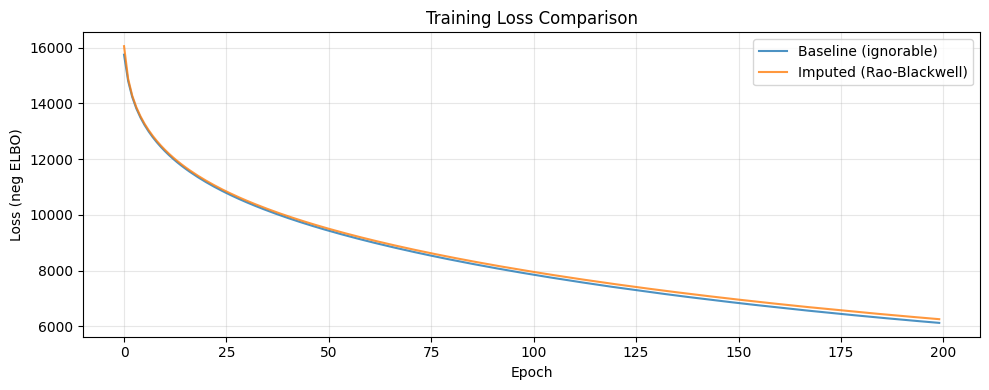

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses_baseline, alpha=0.8, label='Baseline (ignorable)')
ax.plot(losses_imputed, alpha=0.8, label='Imputed (Rao-Blackwell)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (neg ELBO)')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
def calibrate_manually(model, n_samples=32, seed=42):
    surrogate = model.surrogate_distribution_generator(model.params)
    key = jax.random.PRNGKey(seed)
    samples = surrogate.sample(n_samples, seed=key)
    expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
    model.calibrated_expectations = expectations
    model.surrogate_sample = samples

calibrate_manually(model_baseline, n_samples=32, seed=42)
calibrate_manually(model_imputed, n_samples=32, seed=42)
print("Both models calibrated.")

Both models calibrated.


In [ ]:
# Forest plot of discriminations with uncertainty
disc_samples_base = np.array(model_baseline.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))
disc_samples_imp = np.array(model_imputed.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))

disc_mean_base = disc_samples_base.mean(axis=0)
disc_std_base = disc_samples_base.std(axis=0)
disc_mean_imp = disc_samples_imp.mean(axis=0)
disc_std_imp = disc_samples_imp.std(axis=0)

fig, ax = plt.subplots(figsize=(10, max(7, len(item_keys) * 0.4)))
y_pos = np.arange(len(item_keys))
offset = 0.15

ax.errorbar(disc_mean_base, y_pos - offset, xerr=disc_std_base, fmt='o',
            capsize=3, markersize=5, elinewidth=1.5, color='tab:blue',
            ecolor='tab:blue', alpha=0.7, label='Baseline')
ax.errorbar(disc_mean_imp, y_pos + offset, xerr=disc_std_imp, fmt='s',
            capsize=3, markersize=5, elinewidth=1.5, color='tab:orange',
            ecolor='tab:orange', alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels(item_keys)
ax.set_xlabel('Discrimination')
ax.set_title('Item Discriminations (Forest Plot)')
ax.legend()
ax.invert_yaxis()
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(ab_base, ab_imp, alpha=0.3, s=10, edgecolors='none')
lims = [min(ab_base.min(), ab_imp.min()), max(ab_base.max(), ab_imp.max())]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Baseline Ability')
ax.set_ylabel('Imputed Ability')
ax.set_title('Ability Estimates: Baseline vs Imputed')
ax.legend()
ax.set_aspect('equal')

ax = axes[1]
ax.hist(ab_base, bins=30, histtype='step', linewidth=2, label='Baseline', color='tab:blue')
ax.hist(ab_imp, bins=30, histtype='step', linewidth=2, label='Imputed', color='tab:orange')
ax.set_xlabel('Ability (Grit latent trait)')
ax.set_ylabel('Count')
ax.set_title('Ability Distribution')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Difficulty threshold comparison (panel for each level)
def compute_thresholds(model):
    diff0 = np.array(model.surrogate_sample['difficulties0'])
    ddiff = np.array(model.surrogate_sample['ddifficulties'])
    d0 = np.concatenate([diff0, ddiff], axis=-1)
    thresholds = np.cumsum(d0, axis=-1)
    n_samples = thresholds.shape[0]
    n_thresholds = thresholds.size // (n_samples * len(item_keys))
    return thresholds.reshape(n_samples, len(item_keys), n_thresholds)

thresh_base = compute_thresholds(model_baseline)
thresh_imp = compute_thresholds(model_imputed)

K_minus_1 = thresh_base.shape[-1]
n_cols = min(4, K_minus_1)
n_rows = int(np.ceil(K_minus_1 / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
    figsize=(5 * n_cols, max(7, len(item_keys) * 0.4) * n_rows),
    squeeze=False)

for level in range(K_minus_1):
    ax = axes[level // n_cols, level % n_cols]
    y_pos = np.arange(len(item_keys))

    mean_base = thresh_base[:, :, level].mean(axis=0)
    std_base = thresh_base[:, :, level].std(axis=0)
    mean_imp = thresh_imp[:, :, level].mean(axis=0)
    std_imp = thresh_imp[:, :, level].std(axis=0)

    offset = 0.15
    ax.errorbar(mean_base, y_pos - offset, xerr=std_base, fmt='o',
                capsize=2, markersize=4, elinewidth=1, color='tab:blue',
                alpha=0.7, label='Baseline')
    ax.errorbar(mean_imp, y_pos + offset, xerr=std_imp, fmt='s',
                capsize=2, markersize=4, elinewidth=1, color='tab:orange',
                alpha=0.7, label='Imputed')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(item_keys)
    ax.set_title(f'Threshold {level + 1}')
    ax.invert_yaxis()
    if level == 0:
        ax.legend(fontsize=8)

for idx in range(K_minus_1, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Item Difficulty Thresholds: Baseline vs Imputed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Forest plot comparing abilities for 100 random individuals
ab_samples_base = np.array(model_baseline.surrogate_sample['abilities'])
ab_samples_imp = np.array(model_imputed.surrogate_sample['abilities'])

ab_samples_base = ab_samples_base.reshape(ab_samples_base.shape[0], -1)
ab_samples_imp = ab_samples_imp.reshape(ab_samples_imp.shape[0], -1)

N = ab_samples_base.shape[1]
rng = np.random.default_rng(42)
idx = rng.choice(N, size=min(100, N), replace=False)
idx = np.sort(idx)

ab_mean_base = ab_samples_base[:, idx].mean(axis=0)
ab_std_base = ab_samples_base[:, idx].std(axis=0)
ab_mean_imp = ab_samples_imp[:, idx].mean(axis=0)
ab_std_imp = ab_samples_imp[:, idx].std(axis=0)

order = np.argsort(ab_mean_base)
ab_mean_base = ab_mean_base[order]
ab_std_base = ab_std_base[order]
ab_mean_imp = ab_mean_imp[order]
ab_std_imp = ab_std_imp[order]

fig, ax = plt.subplots(figsize=(10, 25))
y_pos = np.arange(len(idx))
offset = 0.15

ax.errorbar(ab_mean_base, y_pos - offset, xerr=ab_std_base, fmt='o',
            capsize=2, markersize=3, elinewidth=1, color='tab:blue',
            alpha=0.7, label='Baseline')
ax.errorbar(ab_mean_imp, y_pos + offset, xerr=ab_std_imp, fmt='s',
            capsize=2, markersize=3, elinewidth=1, color='tab:orange',
            alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'Person {i}' for i in idx[order]], fontsize=5)
ax.set_xlabel('Ability')
ax.set_title('Individual Abilities (100 Random Persons)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated fitting a single-scale Graded Response Model to
all 12 Duckworth Grit Scale items (GS1--GS12) with 5 response categories (0--4).

Two models were compared:

1. **Baseline GRM** -- treats missing responses as ignorable (zeroes out their
   log-likelihood contribution).
2. **Imputed GRM** -- uses a MICEBayesianLOO imputation model to analytically
   marginalize over the imputation distribution for missing cells via
   Rao-Blackwellization.

The discrimination parameters indicate how well each item differentiates
respondents along the single Grit dimension. Comparing the two models
shows the effect of explicitly modelling missingness on parameter estimates.